# Бинарная классификация аудио: Barbie vs Puppy

Классификация аудиофайлов с использованием нейронной сети и аугментации данных

## Импорт библиотек

In [1]:
import os
import numpy as np
import librosa
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import audiomentations as A
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pickle
import kagglehub

## Настройка путей к данным

In [2]:
path = kagglehub.dataset_download("levshaazz/audio-binary-classification-barbie-vs-puppy")

In [3]:
barbie_folder = path + r"\\barbie_vs_puppy\\barbie"
puppy_folder = path + r"\\barbie_vs_puppy\\puppy"

## Получение списка файлов

In [4]:
barbie_files = [os.path.join(barbie_folder, f) for f in os.listdir(barbie_folder) if f.endswith('.wav')]
puppy_files = [os.path.join(puppy_folder, f) for f in os.listdir(puppy_folder) if f.endswith('.wav')]

print(f"Barbie файлов: {len(barbie_files)}")
print(f"Puppy файлов: {len(puppy_files)}")

Barbie файлов: 50
Puppy файлов: 48


## Настройка аугментаций

In [5]:
augment = A.Compose([
    A.AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.005, p=0.3),
    A.TimeStretch(min_rate=0.9, max_rate=1.1, p=0.3),
    A.PitchShift(min_semitones=-2, max_semitones=2, p=0.3),
])

## Функция извлечения признаков

In [6]:
def extract_features(file_path, apply_augmentation=False):
    audio, sr = librosa.load(file_path, sr=22050, duration=3.0)
    
    if apply_augmentation:
        audio = augment(samples=audio, sample_rate=sr)
    
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc, axis=1)
    
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=40)
    mel_mean = np.mean(mel, axis=1)
    
    features = np.concatenate([mfcc_mean, mel_mean])
    
    return features

## Загрузка данных с сохранением путей

In [7]:
X_list = []
y_list = []
file_paths = []

print("Загружаем Barbie файлы...")
for file in barbie_files:
    features = extract_features(file, apply_augmentation=False)
    X_list.append(features)
    y_list.append(0)
    file_paths.append(file)

print("Загружаем Puppy файлы...")
for file in puppy_files:
    features = extract_features(file, apply_augmentation=False)
    X_list.append(features)
    y_list.append(1)
    file_paths.append(file)

X = np.array(X_list)
y = np.array(y_list)
file_paths = np.array(file_paths)

print(f"Форма X: {X.shape}")
print(f"Форма y: {y.shape}")

Загружаем Barbie файлы...
Загружаем Puppy файлы...
Форма X: (98, 53)
Форма y: (98,)


## Разделение данных на train/val/test

In [8]:
indices = np.arange(len(X))

idx_temp, idx_test = train_test_split(indices, test_size=0.2, random_state=42, stratify=y)
idx_train, idx_val = train_test_split(idx_temp, test_size=0.25, random_state=42, stratify=y[idx_temp])

X_train = X[idx_train]
y_train = y[idx_train]
files_train = file_paths[idx_train]

X_val = X[idx_val]
y_val = y[idx_val]

X_test = X[idx_test]
y_test = y[idx_test]

print(f"Train: {len(X_train)} samples")
print(f"Val: {len(X_val)} samples")
print(f"Test: {len(X_test)} samples")

Train: 58 samples
Val: 20 samples
Test: 20 samples


## Аугментация train данных

In [9]:
X_train_aug = []
y_train_aug = []

for file_path in files_train:
    for _ in range(5):
        features = extract_features(file_path, apply_augmentation=True)
        X_train_aug.append(features)
        idx = np.where(file_paths == file_path)[0][0]
        y_train_aug.append(y[idx])

X_train_combined = np.vstack([X_train, np.array(X_train_aug)])
y_train_combined = np.concatenate([y_train, np.array(y_train_aug)])

print(f"Train после аугментации: {len(X_train_combined)} samples")

Train после аугментации: 348 samples


## Нормализация данных

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_combined)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Данные нормализованы")

Данные нормализованы


## Создание архитектуры модели

In [11]:
def create_model(input_shape):
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

## Обучение модели на train/val

In [12]:
model = create_model(X_train_scaled.shape[1])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001
)

history = model.fit(
    X_train_scaled, y_train_combined,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=8,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5632 - loss: 0.7759 - val_accuracy: 0.7500 - val_loss: 0.6135 - learning_rate: 0.0010
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6207 - loss: 0.6858 - val_accuracy: 0.7500 - val_loss: 0.5848 - learning_rate: 0.0010
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6868 - loss: 0.5878 - val_accuracy: 0.7500 - val_loss: 0.5546 - learning_rate: 0.0010
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7069 - loss: 0.5571 - val_accuracy: 0.7500 - val_loss: 0.5413 - learning_rate: 0.0010
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7414 - loss: 0.4866 - val_accuracy: 0.7500 - val_loss: 0.5296 - learning_rate: 0.0010
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7931 - loss: 0.4599 - val_accuracy: 0.7500 - val_loss: 0.5129 - learning_rate: 0.0010
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7874 - loss: 0.4217 - val_acc

## Визуализация обучения

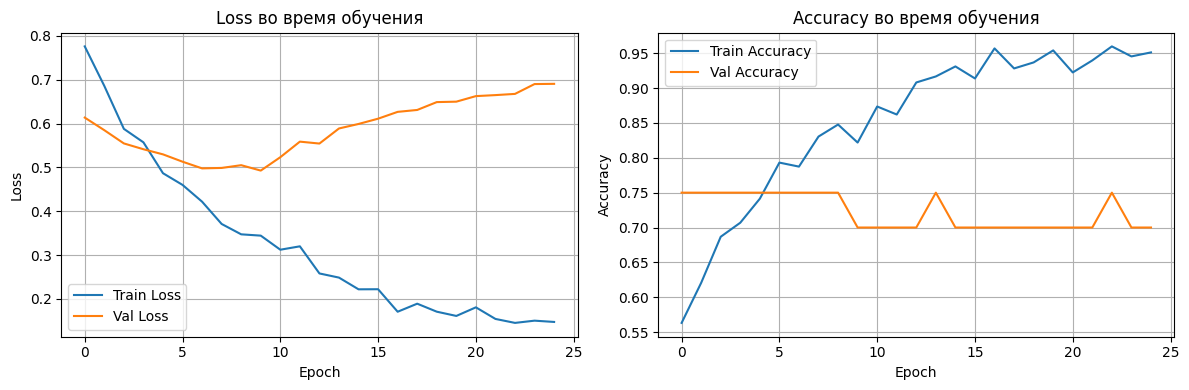

In [13]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss во время обучения')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy во время обучения')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Оценка модели на всех выборках

In [14]:
train_loss, train_acc = model.evaluate(X_train_scaled, y_train_combined, verbose=0)
val_loss, val_acc = model.evaluate(X_val_scaled, y_val, verbose=0)
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

print("=" * 50)
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Val Accuracy:   {val_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print("=" * 50)
print(f"Разница Train-Val: {abs(train_acc - val_acc):.4f}")
print(f"Разница Train-Test: {abs(train_acc - test_acc):.4f}")

Train Accuracy: 0.9339
Val Accuracy:   0.7000
Test Accuracy:  0.7500
Разница Train-Val: 0.2339
Разница Train-Test: 0.1839


## K-Fold Cross-Validation

In [15]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []
fold_num = 1

for train_idx, val_idx in kfold.split(X, y):
    print(f"\n--- FOLD {fold_num}/5 ---")
    
    X_fold_train = X[train_idx]
    y_fold_train = y[train_idx]
    files_fold_train = file_paths[train_idx]
    
    X_fold_val = X[val_idx]
    y_fold_val = y[val_idx]
    
    X_aug_fold = []
    y_aug_fold = []
    
    for file_path in files_fold_train:
        for _ in range(3):
            features = extract_features(file_path, apply_augmentation=True)
            X_aug_fold.append(features)
            idx = np.where(file_paths == file_path)[0][0]
            y_aug_fold.append(y[idx])
    
    X_fold_train_final = np.vstack([X_fold_train, np.array(X_aug_fold)])
    y_fold_train_final = np.concatenate([y_fold_train, np.array(y_aug_fold)])
    
    scaler_fold = StandardScaler()
    X_fold_train_scaled = scaler_fold.fit_transform(X_fold_train_final)
    X_fold_val_scaled = scaler_fold.transform(X_fold_val)
    
    model_fold = create_model(X_fold_train_scaled.shape[1])
    model_fold.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    model_fold.fit(
        X_fold_train_scaled, y_fold_train_final,
        validation_data=(X_fold_val_scaled, y_fold_val),
        epochs=50,
        batch_size=8,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        ],
        verbose=0
    )
    
    val_loss, val_acc = model_fold.evaluate(X_fold_val_scaled, y_fold_val, verbose=0)
    fold_results.append(val_acc)
    
    print(f"Fold {fold_num} Validation Accuracy: {val_acc:.4f}")
    fold_num += 1

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ CROSS-VALIDATION:")
print("=" * 60)
print(f"Accuracy по каждому fold: {[f'{x:.4f}' for x in fold_results]}")
print(f"Средняя accuracy: {np.mean(fold_results):.4f} ± {np.std(fold_results):.4f}")
print("=" * 60)


--- FOLD 1/5 ---
Fold 1 Validation Accuracy: 0.7500

--- FOLD 2/5 ---
Fold 2 Validation Accuracy: 0.7500

--- FOLD 3/5 ---
Fold 3 Validation Accuracy: 0.7000

--- FOLD 4/5 ---
Fold 4 Validation Accuracy: 0.8947

--- FOLD 5/5 ---
Fold 5 Validation Accuracy: 0.7368

РЕЗУЛЬТАТЫ CROSS-VALIDATION:
Accuracy по каждому fold: ['0.7500', '0.7500', '0.7000', '0.8947', '0.7368']
Средняя accuracy: 0.7663 ± 0.0668


## Обучение финальной модели на всех данных

In [16]:
X_final_all = []
y_final_all = []

for file_path in file_paths:
    features_orig = extract_features(file_path, apply_augmentation=False)
    X_final_all.append(features_orig)
    idx = np.where(file_paths == file_path)[0][0]
    y_final_all.append(y[idx])
    
    for _ in range(4):
        features_aug = extract_features(file_path, apply_augmentation=True)
        X_final_all.append(features_aug)
        y_final_all.append(y[idx])

X_final_all = np.array(X_final_all)
y_final_all = np.array(y_final_all)

scaler_final = StandardScaler()
X_final_scaled = scaler_final.fit_transform(X_final_all)

model_final = create_model(X_final_scaled.shape[1])
model_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_final = model_final.fit(
    X_final_scaled, y_final_all,
    epochs=50,
    batch_size=8,
    verbose=1
)

print(f"\nФинальная модель обучена на {len(X_final_all)} samples")
print(f"Train accuracy: {history_final.history['accuracy'][-1]:.4f}")

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5571 - loss: 0.8137
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5939 - loss: 0.6672
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6653 - loss: 0.5946
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7041 - loss: 0.5530
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7531 - loss: 0.4985  
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7633 - loss: 0.4513
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7857 - loss: 0.4543
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8143 - loss: 0.4102
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8265 - loss: 0.4110
Epoch 10/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8367 - loss: 0.3760
Epoch 11/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8429 - loss: 0.3374
Epoch 12/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8571 - 

## График обучения финальной модели

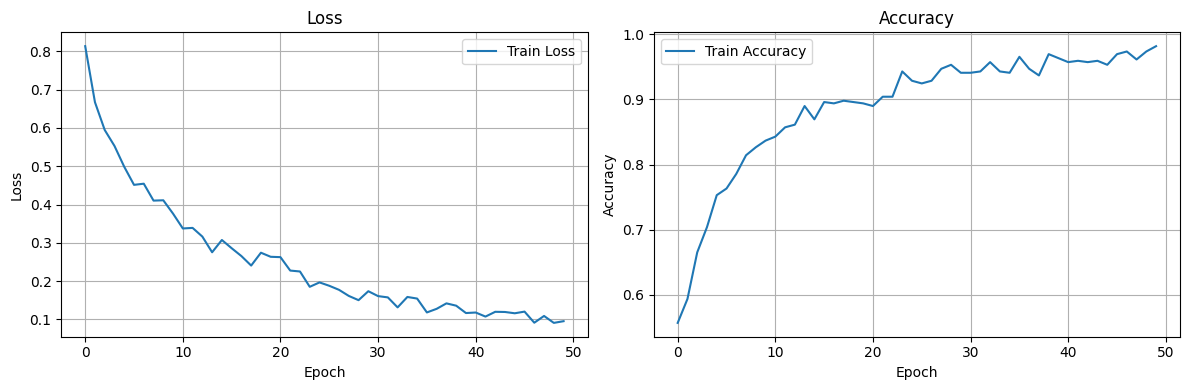

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_final.history['loss'], label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_final.history['accuracy'], label='Train Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Функция для предсказания на новых данных

In [19]:
def predict_audio(file_path, model, scaler):
    features = extract_features(file_path, apply_augmentation=False)
    features = features.reshape(1, -1)
    features_scaled = scaler.transform(features)
    prediction = model.predict(features_scaled, verbose=0)[0][0]
    
    if prediction > 0.5:
        return "Puppy", prediction
    else:
        return "Barbie", 1 - prediction

## Пример использования

In [20]:
test_file = barbie_files[0]
label, confidence = predict_audio(test_file, model_final, scaler_final)
print(f"Файл: {os.path.basename(test_file)}")
print(f"Предсказание: {label}")
print(f"Уверенность: {confidence:.2%}")

Файл: barbie_0.wav
Предсказание: Barbie
Уверенность: 100.00%
